## AI Search Agentic Retreval

You should use agentic retrieval when you want to send high quality data to an agent or to ground a chat experience with inputs that include your proprietary content.

The agentic aspect is a reasoning step in query planning processing that's performed by a supported large language model (LLM) that you provide. The LLM analyzes the entire chat thread to identify the underlying information need. Instead of a single, catch-all query, the model breaks down compound questions into focused subqueries based on: user questions, chat history, and parameters on the request. The subqueries target your indexed documents (plain text and vectors) in Azure AI Search.This hybrid approach ensures you surface both keyword matches and semantic similarities at once, dramatically improving recall.

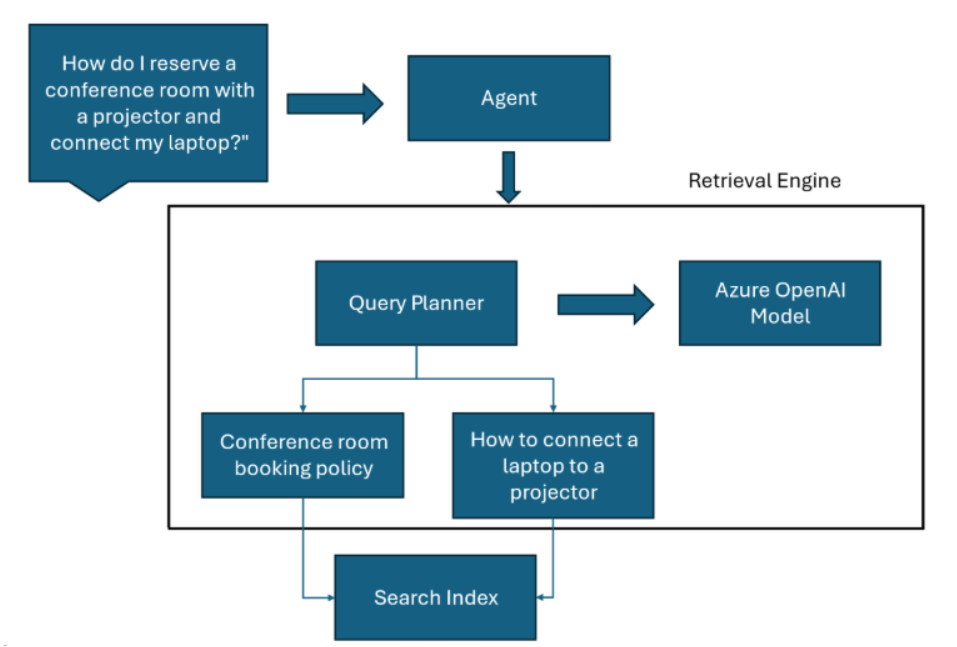

#### Create index if it does not exist

In [4]:
#pip install azure-search-documents==11.6.0b12
#https://github.com/Azure-Samples/azure-search-python-samples/blob/main/Quickstart-Agentic-Retrieval/quickstart-agentic-retrieval.ipynb

from dotenv import load_dotenv
from azure.identity import DefaultAzureCredential, get_bearer_token_provider
import os
from azure.core.credentials import AzureKeyCredential
from azure.search.documents.indexes.models import KnowledgeAgent, KnowledgeAgentAzureOpenAIModel, KnowledgeAgentTargetIndex, KnowledgeAgentRequestLimits, AzureOpenAIVectorizerParameters
from azure.search.documents.indexes import SearchIndexClient

import configparser; config = configparser.RawConfigParser()
config.read('keys//keys.ini')
api_key = config['keys']['AzureEUS2Proj']

agent = KnowledgeAgent(
    name="aisearchagentdemo",
    models=[
        KnowledgeAgentAzureOpenAIModel(
            azure_open_ai_parameters=AzureOpenAIVectorizerParameters(
                resource_url="https://foundryeusv24264390516.openai.azure.com/",
                deployment_name="gpt4om",
                model_name="gpt-4o-mini",
                api_key=api_key,
            )
        )
    ],
    target_indexes=[
        KnowledgeAgentTargetIndex(
            index_name="buffyvec",
            default_reranker_threshold=2.5
        )
    ],
)

import configparser; config = configparser.RawConfigParser()
config.read('keys//keys.ini')
search_key = config['keys']['AzureSearchKey']

endpoint = 'https://rgoaisearch.search.windows.net'
#credential = DefaultAzureCredential()
credential = AzureKeyCredential(search_key)

index_client = SearchIndexClient(endpoint=endpoint, credential=credential, semantic_search_enabled=True)
ilist = index_client.list_index_names()
for item in ilist:
    print(item)
index_client.create_or_update_agent(agent)
print(f"Knowledge agent created or updated successfully")

adlsgen2-index
alicefromwizard
alicevectorl3
blobstorage-index
buffyvec
stationdesign
vectorsearch
Knowledge agent created or updated successfully


In [10]:
from azure.search.documents.agent import KnowledgeAgentRetrievalClient
from azure.search.documents.agent.models import KnowledgeAgentRetrievalRequest, KnowledgeAgentMessage, KnowledgeAgentMessageTextContent, KnowledgeAgentIndexParams

import configparser; config = configparser.RawConfigParser()
config.read('keys//keys.ini')
AzureSearchKey = config['keys']['AzureSearchKey']

endpoint = 'https://rgoaisearch.search.windows.net'
credential = AzureKeyCredential(AzureSearchKey)
agent_client = KnowledgeAgentRetrievalClient(endpoint=endpoint, agent_name="aisearchagentdemo", credential=credential)

instructions = """
A Q&A agent that can answer questions about the Buffy the Vampire Slayer.
If you do not have the answer, respond with "I don't know".
"""
messages = [
    {
        "role": "system",
        "content": instructions
    }
]

messages.append({
    "role": "user",
    "content": """
    What was Faith's beef with Buffy and how did it end, also was she better at kiling vampires?
    """
})

retrieval_result = agent_client.retrieve(
    retrieval_request=KnowledgeAgentRetrievalRequest(
        messages=[KnowledgeAgentMessage(role=msg["role"], content=[KnowledgeAgentMessageTextContent(text=msg["content"])]) for msg in messages if msg["role"] != "system"],
        target_index_params=[KnowledgeAgentIndexParams(index_name="buffyvec", reranker_threshold=2.5)]
    )
)
messages.append({
    "role": "assistant",
    "content": retrieval_result.response[0].content[0].text
})

In [11]:
import json
print("Activity")
print(json.dumps([a.as_dict() for a in retrieval_result.activity], indent=2))


Activity
[
  {
    "id": 0,
    "type": "ModelQueryPlanning",
    "input_tokens": 1362,
    "output_tokens": 528
  },
  {
    "id": 1,
    "type": "AzureSearchQuery",
    "target_index": "buffyvec",
    "query": {
      "search": "What was the nature of Faith's conflict with Buffy and how did it conclude? Was Faith better at slaying vampires?"
    },
    "query_time": "2026-01-29T10:41:42.091Z",
    "count": 38,
    "elapsed_ms": 1350
  },
  {
    "id": 2,
    "type": "AzureSearchQuery",
    "target_index": "buffyvec",
    "query": {
      "search": "How did Faith's rivalry with Buffy end? Was Faith more effective at killing vampires?"
    },
    "query_time": "2026-01-29T10:41:42.842Z",
    "count": 5,
    "elapsed_ms": 740
  },
  {
    "id": 3,
    "type": "AzureSearchSemanticRanker",
    "input_tokens": 51512
  }
]


In [7]:
print("Results")
print(json.dumps([r.as_dict() for r in retrieval_result.references], indent=2))

Results
[
  {
    "type": "AzureSearchDoc",
    "id": "0",
    "activity_source": 1,
    "doc_key": "513a4c9ffffb_aHR0cHM6Ly9iaWdkYXRhZmlsZXNyYWwuYmxvYi5jb3JlLndpbmRvd3MubmV0L2J1ZmZ5LzN4MDclMjBSZXZlbGF0aW9ucy50eHQ1_pages_4"
  },
  {
    "type": "AzureSearchDoc",
    "id": "2",
    "activity_source": 1,
    "doc_key": "513a4c9ffffb_aHR0cHM6Ly9iaWdkYXRhZmlsZXNyYWwuYmxvYi5jb3JlLndpbmRvd3MubmV0L2J1ZmZ5LzN4MDclMjBSZXZlbGF0aW9ucy50eHQ1_pages_2"
  },
  {
    "type": "AzureSearchDoc",
    "id": "3",
    "activity_source": 1,
    "doc_key": "f1a8e3d93718_aHR0cHM6Ly9iaWdkYXRhZmlsZXNyYWwuYmxvYi5jb3JlLndpbmRvd3MubmV0L2J1ZmZ5LzR4MTYlMjBXaG8lMjBBcmUlMjBZb3UudHh00_pages_23"
  },
  {
    "type": "AzureSearchDoc",
    "id": "4",
    "activity_source": 1,
    "doc_key": "8ec782570810_aHR0cHM6Ly9iaWdkYXRhZmlsZXNyYWwuYmxvYi5jb3JlLndpbmRvd3MubmV0L2J1ZmZ5LzN4MTUlMjBDb25zZXF1ZW5jZXMudHh00_pages_27"
  },
  {
    "type": "AzureSearchDoc",
    "id": "5",
    "activity_source": 1,
    "doc_key": "a66e953efeac_aH

In [21]:
# import textwrap

# print("Response")
# print(textwrap.fill(retrieval_result.response[0].content[0].text, width=120))

In [8]:
#Put the responses into a nice format
from openai import AzureOpenAI
import textwrap

import configparser; config = configparser.RawConfigParser()
config.read('keys//keys.ini')
api_key = config['keys']['AzureEUS2Proj']

client = AzureOpenAI(
    azure_endpoint="https://foundryeusv24264390516.openai.azure.com/",
    api_key=api_key,
    api_version="2025-03-01-preview"
)

response = client.responses.create(
    model="gpt4om",
    input=messages
)

wrapped = textwrap.fill(response.output_text, width=100)
print(wrapped)


Faith's beef with Buffy stemmed from their contrasting views on being a Slayer and personal
morality. Faith embraced a more ruthless and hedonistic approach to slaying, reveling in the thrill
of violence, while Buffy adhered to a more principled stance of protecting people. This difference
created tension between them, especially when Faith killed a human in cold blood, which deeply
troubled Buffy.  Their conflict escalated, leading to a physical confrontation where Buffy accused
Faith of being reckless and dangerous. Eventually, Faith's journey took her to a dark place, and she
became an antagonist before ultimately seeking redemption. Their relationship evolved throughout the
series, culminating in Faith's return in later seasons when she sought to make amends.  As for being
better at killing vampires, Faith often displayed a more aggressive fighting style and had a
reputation for being more brutal. While they both had strengths, Faith's approach often led her to
be more effective in